* Creating a conditional non-llm workflow where user will provide
a,b,c values and we will find the solution(roots) of that quadratic equation.

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [5]:
class QuadState(TypedDict):
    a: int 
    b: int 
    c: int 
    
    equation: str 
    discriminant: float
    result: str

In [15]:
def show_equation(state: QuadState):
    eq = f"{state['a']}x^2 + {state['b']}x + {state['c']}"
    return {
        "equation": eq
    }

In [16]:
def calculate_discriminant(state: QuadState):
    discriminant = state['b']**2 - (4 * state['a'] * state['c'])
    return {
        "discriminant" : discriminant 
    }

In [17]:
def real_roots(state: QuadState):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2 * state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2 * state['a'])
    result = f"The roots are: {root1} and {root2}"
    return {
        "result": result
    }

In [18]:
def repeated_roots(state: QuadState):
    root = (-state['b']) / (2 * state['a'])
    result = f"The roots are: {root} and {root}"
    return {
        "result": result
    }

In [19]:
def no_real_roots(state: QuadState):
    result = "No real roots"
    return {
        "result": result
    }

In [20]:
from typing import  Literal
def check_discriminant(state: QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:
    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

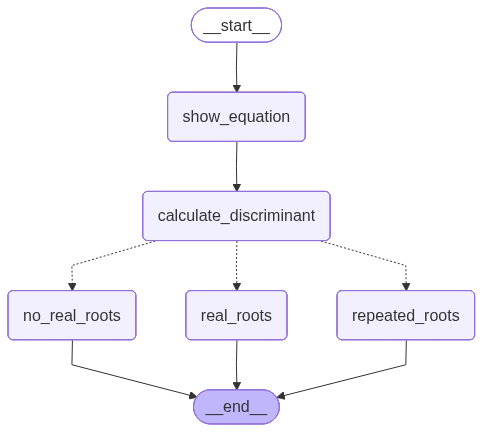

In [21]:
graph = StateGraph(QuadState)

graph.add_node("show_equation" , show_equation)
graph.add_node("calculate_discriminant" , calculate_discriminant)
graph.add_node("real_roots" , real_roots)
graph.add_node("repeated_roots" , repeated_roots)
graph.add_node("no_real_roots" , no_real_roots)


graph.add_edge(START , "show_equation")
graph.add_edge("show_equation" , "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant" , check_discriminant)
graph.add_edge("real_roots" , END)
graph.add_edge("repeated_roots" , END)
graph.add_edge("no_real_roots" , END)

quad_workflow = graph.compile()
quad_workflow

In [22]:
final_state = quad_workflow.invoke({
    "a": 2,
    "b": 5,
    "c": 3
})
final_state

{'a': 2,
 'b': 5,
 'c': 3,
 'equation': '2x^2 + 5x + 3',
 'discriminant': 1,
 'result': 'The roots are: -1.0 and -1.5'}

### LLM Conditional Workflow
Creating a LLM workflow. We will take take a review from customer. And analysis the 
sentiment of the review as a structured output.
* if review is positive then give a positive response(Thank you message).
* if review is negative:
    - Run a diagnosis on the review
    - give  a negative response

In [23]:
from pydantic import BaseModel, Field

In [35]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [25]:
from langchain_ollama import ChatOllama
phi_model = ChatOllama(
    model = "phi4-mini:latest"
)

In [27]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive' , 'negative'] = Field(
        description = "sentiment of the review"
    )

In [30]:
structured_model = phi_model.with_structured_output(SentimentSchema)
response = structured_model.invoke("The laptop is too slow and poor charge backup")

In [39]:
res = phi_model.invoke("hello")
res

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'phi4-mini:latest', 'created_at': '2026-05-12T06:19:34.378588Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1924720500, 'load_duration': 1817070800, 'prompt_eval_count': 4, 'prompt_eval_duration': 27805500, 'eval_count': 10, 'eval_duration': 67762400, 'logprobs': None, 'model_name': 'phi4-mini:latest', 'model_provider': 'ollama'}, id='lc_run--019e1ad7-36e4-7801-957f-718c247b6c27-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 4, 'output_tokens': 10, 'total_tokens': 14})

In [40]:
res.content

'Hello! How can I assist you today?'

In [31]:
response.sentiment

'negative'

In [29]:
class AgentState(TypedDict):
    review: str 
    sentiment: Literal['positive' , 'negative']
    diagonsis: dict  
    response: str 

In [42]:
class DiagonsisSchema(BaseModel):
    issue_type: Literal["UX","Performance","Bug","Support","Other"] = Field(
        description = "The category of the issue mentioned in the review"
    )
    tone: Literal["angry","frustrated","disappointed","calm"] = Field(
        description = "The emotional tone expressed by the user"
    )
    urgency: Literal["low","medium","high"] = Field(
        description = "How urgent or critical the issue apears to be"
    )

In [33]:
def sentiment_analysis(state: AgentState):
    global structured_model
    prompt = f"""You are an expert sentiment analyzer. 
    Based on the given review analyze the sentiment of the review.\n 
    Review:\n{state['review']}\n\n 
    Returns:
     - positive
     - negative 
    """ 
    response = structured_model.invoke(prompt)
    return {
        "sentiment": response.sentiment
    }

In [49]:
diagonsis__model = phi_model.with_structured_output(DiagonsisSchema)
prompt = f"""Do a diagnosis analysis on the following review:

I bought this laptop but it poor charge backup along with few software
are stopping without notifying me. My exam is very near and I need the fix so that
I complete my project works. 
"""
response = diagonsis__model.invoke(prompt)

In [55]:
response.model_dump()

{'issue_type': 'Performance', 'tone': 'frustrated', 'urgency': 'high'}

In [56]:
def run_diagnosis(state: AgentState):
    global phi_model
    diagonsis__model = phi_model.with_structured_output(DiagonsisSchema)
    prompt = f"""Do a diagnosis analysis on the following review:\n\n{state['review']}"""
    response = diagonsis__model.invoke(prompt)
    return {
        "diagonsis": response.model_dump()
    }

In [57]:
def write_positive_response(state: AgentState):
    global phi_model
    prompt =  f"""Write a warm thank you message in response to this review:\n\n 
    Review: {state['review']} \n\n 
    Also kindly ask the user to leave a feedback on our website.
    """
    response = phi_model.invoke(prompt)
    return {
        "response" : response.content
    }

In [58]:
def write_negative_response(state: AgentState):
    global phi_model
    prompt = f"""You are an expert customer support agent. Your customer provided a negative review.
    Now give him/her a response message base the review and diagonsis report.\n\n
    
    **Review**: {state['review']} \n\n 
    **Digonsis Report**: {state['diagonsis']}. 
    """ 
    response = phi_model.invoke(prompt)
    return {
        "response" : response.content
    }

In [59]:
def senstiment_check(state: AgentState):
    if state['sentiment'] == "positive":
        return "write_positive_response"
    else:
        return "run_diagnosis"

In [60]:
graph = StateGraph(AgentState)

graph.add_node("sentiment_analysis" , sentiment_analysis)
graph.add_node("run_diagnosis" , run_diagnosis)
graph.add_node("write_positive_response" , write_positive_response)
graph.add_node("write_negative_response" , write_negative_response)


graph.add_edge(START , "sentiment_analysis")
graph.add_conditional_edges("sentiment_analysis" , senstiment_check)
graph.add_edge("run_diagnosis" , "write_negative_response")
graph.add_edge("write_negative_response" , END)
graph.add_edge("write_positive_response" , END)

review_workflow = graph.compile()

In [61]:
result = review_workflow.invoke({
    "review" : """I bought this laptop but it poor charge backup along with few software
    are stopping without notifying me. My exam is very near and I need the fix so that
    I complete my project works. 
    """
})

In [63]:
print(result['response'])

Dear Valued Customer,

Thank you for taking time to share your feedback regarding our laptop purchase and the issues you've encountered with its performance.

We are genuinely sorry that this experience has caused significant inconvenience, especially given how crucial completing your project work is ahead of an exam. Our top priority at [Company Name] remains customer satisfaction; thus, we would like to address these concerns promptly for you.

**Performance Issues:**
- **Charging Back-up:** We apologize deeply as the poor charging backup and software failures have affected our laptop's performance significantly.
  
**Urgency & Resolution Plan:**

1. **Immediate Software Update/Safety Checkup**:
   - A dedicated technical support team will reach out to your device within 24 hours for an urgent diagnostic check, which includes running a comprehensive safety scan on the system and updating all software components.

2. **Hardware Inspection/Replacement Process (if necessary)**: 
   - If